# Analyze single sample

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
import sys

In [248]:
# data_folder = "/data/proj/pangebin/data"

data_folder = "./data/"
result_csv = "result.csv"
test_id = 'test_data'

In [249]:
def read_score_to_tuple(sample, score, input_type, mix):
    cols = ["sample", "model", "bintype", "tool", "prec", "rec", "f1"]
    out_tuple = pd.DataFrame(columns=cols)

    # out_tuple = pd.DataFrame(columns=cols)
    # voglio leggere i file .txt del typo "score" (lab o bin) e del tipo "input_type" (ske, uni, pan)
    # e metterli in un dataframe
    # se input type == pan allora devo fare la "media" dei valori di ske e uni
    # riguardo al tipo di bin: uni e ske hanno solo pred, mentre pan ha anche naive e graph-overlap
    for filename in os.listdir(sample):
        fields = filename.split(".")
        if (not filename.endswith(".txt")): # salto i file non txt, non sono file di score
            continue
        _sample = fields[0] #nome del sample
        _type = fields[1] # tipo in input {ske, uni, pan}
        _thr = fields[2] # threshold (default 1)
        _model = fields[3] # modello {pbf, ml}, default pbf
        assert(_model == "pbf")
        _score = fields[-2] # score {lab, bin} labeling o binning
        _ref = fields[-3] # reference {uni, ske}
        _bins = fields[-4] # tipo di binning {pred, nve, ovl} pred= predizione del modello, nve= naive, ovl= graph-overlap
        
        if _type == input_type:
            if _score == "lab" and score == "lab": # se il tipo di score del file è del tipo richiesto
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())

            elif _score == "bin" and score == "bin":
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
            else:
                continue
            out_tuple = pd.concat([pd.DataFrame([[_sample, _model, _bins, f"{_thr}.{_type}", prec, rec, f1]], columns=cols), out_tuple if not out_tuple.empty else None], ignore_index=True)

        else:
            continue
        # print(out_tuple)
        if len(out_tuple) > 1:
            out_tuple = out_tuple.groupby(["sample", "model", "bintype", "tool"]).mean(numeric_only=True).reset_index()
            # out_tuple.insert(loc=3, column="tool", value = f"{_thr}.{_type}")
            if (mix):
                out_tuple = out_tuple.groupby(["sample", "model", "tool"]).max(numeric_only=True).reset_index()
                out_tuple.insert(loc=2, column="bintype", value = f"pred")
                # out_tuple.insert(loc=3, column="tool", value = f"{_thr}.{_type}")

    return out_tuple

In [250]:
#iterate over all samples
df_labeling = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_labeling_mix = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_binning = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_binning_mix = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
for file in os.listdir(data_folder):
    sample = data_folder + file
    for input_type in ["ske", "uni", "pan"]:
        df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=False), df_labeling if not df_labeling.empty else None], ignore_index=True)
        df_labeling_mix = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=True), df_labeling_mix if not df_labeling_mix.empty else None], ignore_index=True)

        df_binning = pd.concat([read_score_to_tuple(sample, "bin", input_type, mix=False), df_binning if not df_binning.empty else None], ignore_index=True)
        df_binning_mix = pd.concat([read_score_to_tuple(sample, "bin", input_type, mix=True), df_binning_mix if not df_binning_mix.empty else None], ignore_index=True)


df_labeling.to_csv(f"{test_id}.labeling.csv", sep='\t', index=False)
df_binning.to_csv(f"{test_id}.binning.csv", sep='\t', index=False)

df_labeling_mix.to_csv(f"{test_id}.labeling.mix.csv", sep='\t', index=False)
df_binning_mix.to_csv(f"{test_id}.binning.mix.csv", sep='\t', index=False)



/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3458152767.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=False), df_labeling if not df_labeling.empty else None], ignore_index=True)
/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3458152767.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling_mix = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=True), df_lab

<Figure size 1000x600 with 0 Axes>

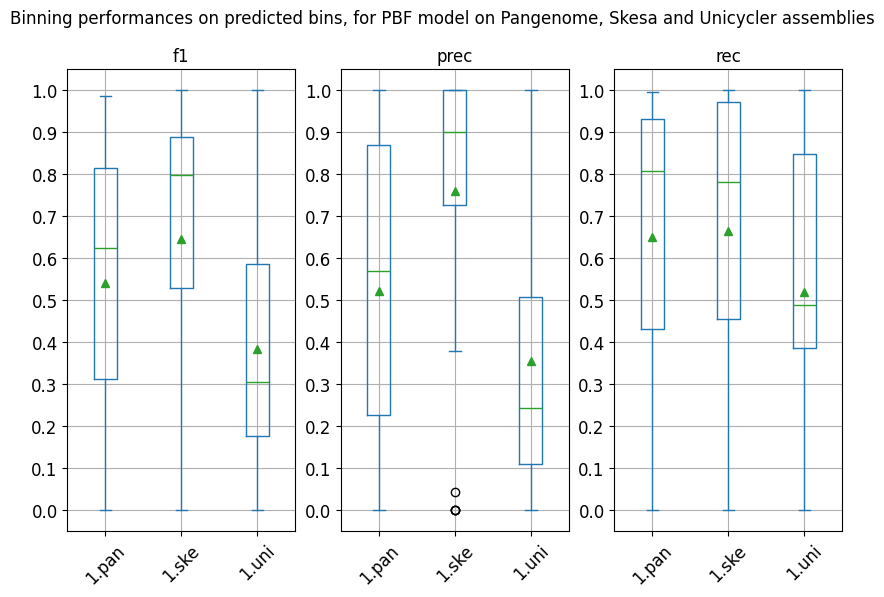

In [251]:
#Plotting pdf.bintype=pred
plt.figure(figsize=(10, 6))
plt.show()

plot_1 = df_binning.loc[df_binning["bintype"]=='pred'].plot.box(by=["tool"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title="Binning performances on predicted bins, for PBF model on Pangenome, Skesa and Unicycler assemblies")



<Figure size 1000x600 with 0 Axes>

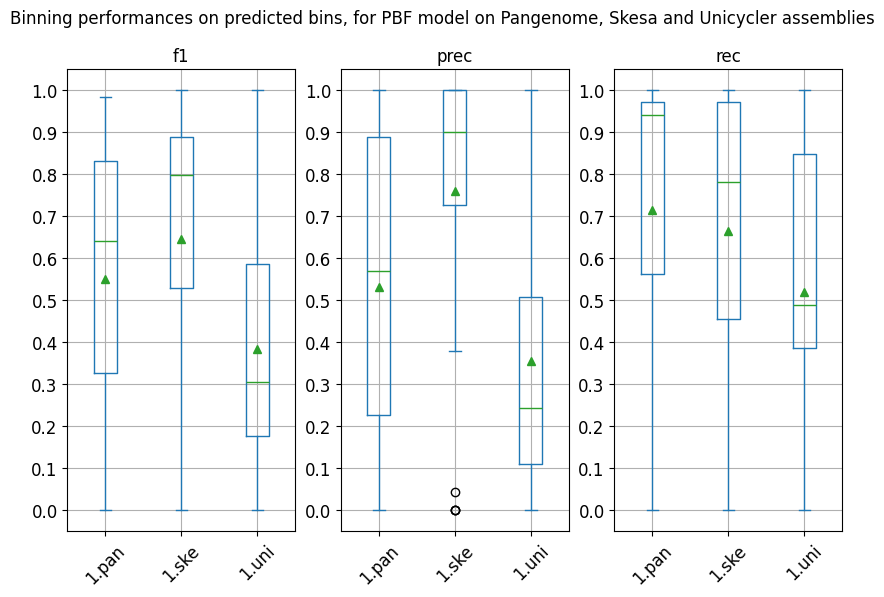

In [252]:
#Plotting pdf.bintype=pred
plt.figure(figsize=(10, 6))
plt.show()

plot_1a = df_binning_mix.plot.box(by=["tool"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title="Binning performances on predicted bins, for PBF model on Pangenome, Skesa and Unicycler assemblies")


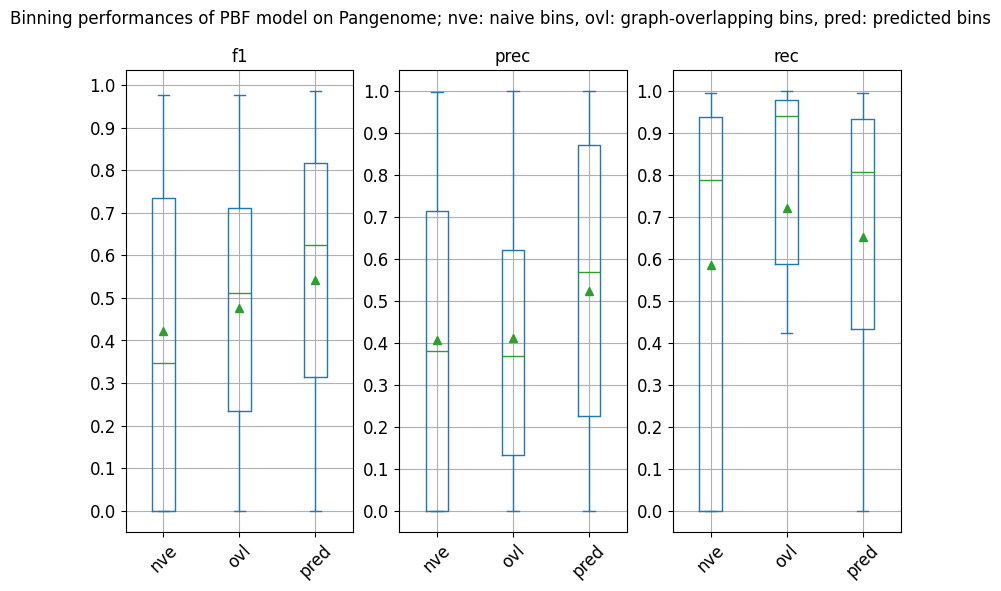

In [253]:
plot_2 = df_binning.loc[df_binning["tool"]=='1.pan'].plot.box(by=["bintype"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title = "Binning performances of PBF model on Pangenome; nve: naive bins, ovl: graph-overlapping bins, pred: predicted bins")


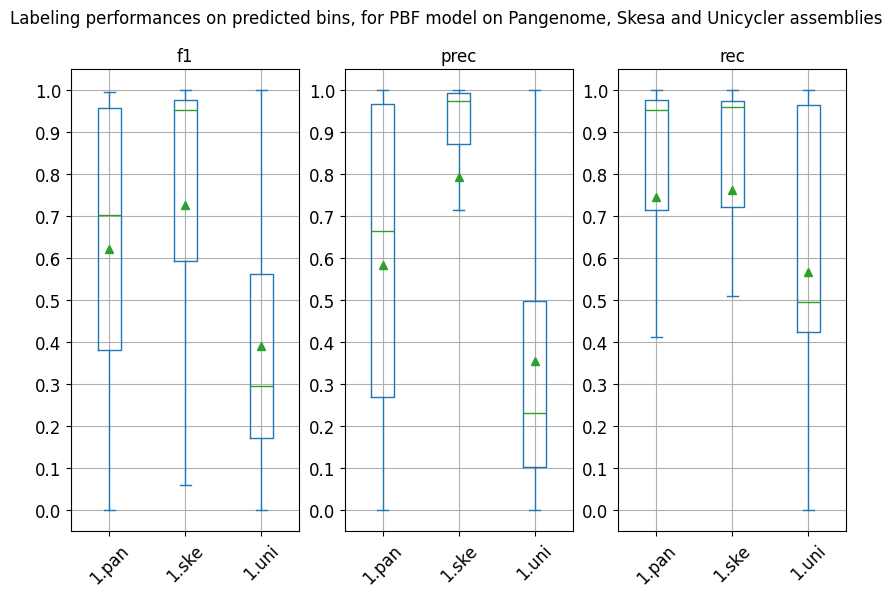

In [254]:
plot_3 = df_labeling.loc[df_labeling["bintype"]=='pred'].plot.box(by=["tool"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title="Labeling performances on predicted bins, for PBF model on Pangenome, Skesa and Unicycler assemblies")


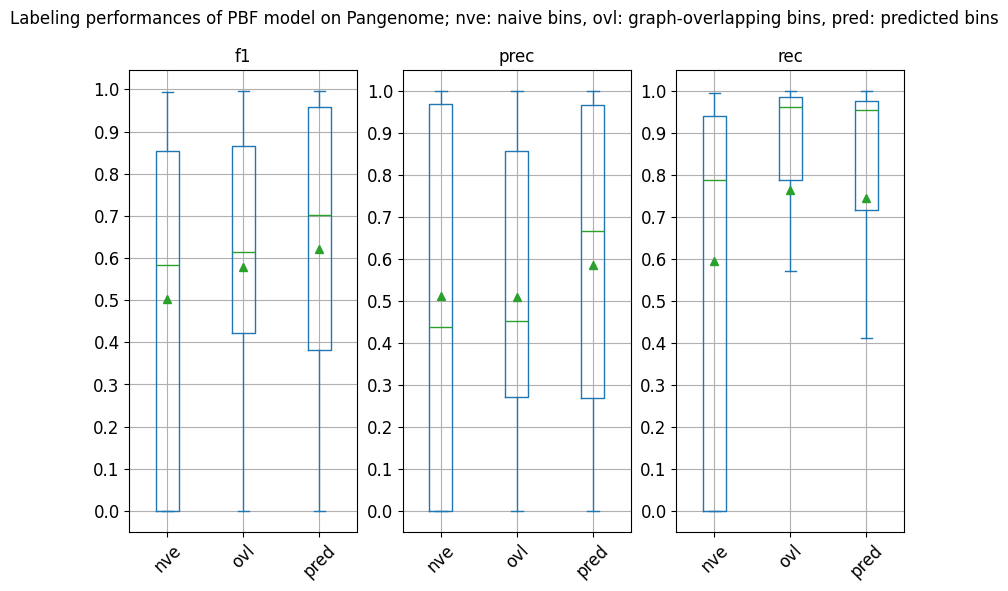

In [255]:
plot_4 = df_labeling.loc[df_labeling["tool"]=='1.pan'].plot.box(by=["bintype"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title = "Labeling performances of PBF model on Pangenome; nve: naive bins, ovl: graph-overlapping bins, pred: predicted bins")